/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


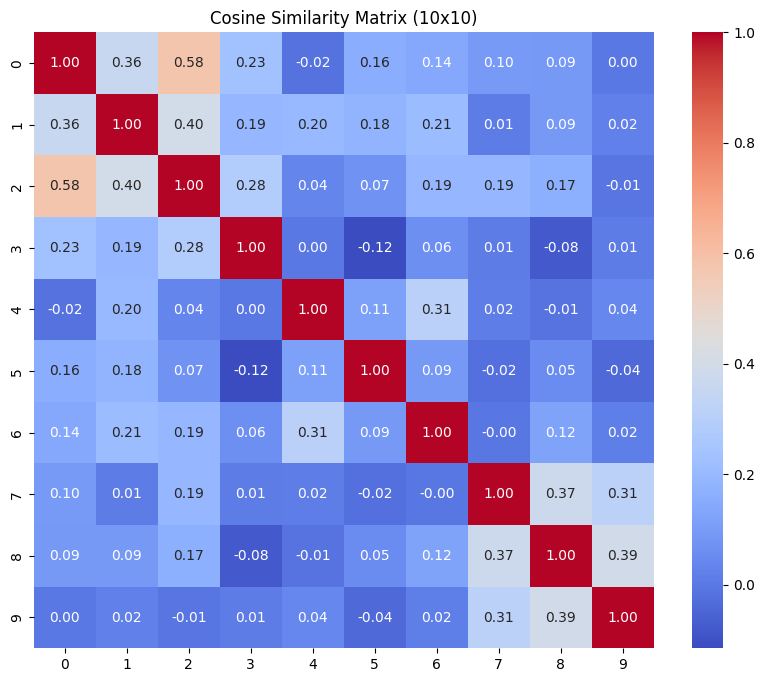

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: India won the cricket match by six wickets
Similarity Score: 0.4063

Sentence: The batsman scored a century in the final match
Similarity Score: 0.1414



In [1]:
!pip install chromadb sentence-transformers seaborn matplotlib
import chromadb
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

client = chromadb.Client()

collection = client.create_collection(name="sentence_embeddings")

sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match",
    "The bowler delivered a perfect yorker",
    "India won the cricket match by six wickets",
    "The team celebrated their victory on the field",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements",
    "She cooked a spicy curry for dinner",

    # Cybersecurity (3)
    "The system was protected using advanced encryption techniques",
    "Cyber attacks can compromise sensitive data",
    "A firewall helps prevent unauthorized access to networks"
]

embeddings = model.encode(sentences)

collection.add(
    documents=sentences,
    embeddings=embeddings.tolist(),
    ids=[f"id_{i}" for i in range(len(sentences))]
)

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cosine Similarity Matrix (10x10)")
plt.show()

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query]).tolist()

results = collection.query(
    query_embeddings=query_embedding,
    n_results=2
)

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for doc, dist in zip(results['documents'][0], results['distances'][0]):
    print(f"Sentence: {doc}")
    print(f"Similarity Score: {1 - dist:.4f}")  # Convert distance to similarity
    print()